# AccessMap: Network for Persons With Reduced Mobility

## Project Description
This notebook explores Amsterdam's "Network for Persons With Reduced Mobility" dataset. It describes a pedestrian network for people with reduced mobility, like wheelchair users, across two districts: Nieuwmarkt-Lastage and Osdorp-Midden. This is the first of three notebooks. This one covers the PMR dataset only.

## Dataset
- **Source:** Kaggle - Amsterdam Intelligence
- **File:** accessibility_dataset.gpkg (GeoPackage, may contain multiple layers)
- **Link:** https://www.kaggle.com/datasets/amsintelligence/network-for-persons-with-reduced-mobility

## Project Roadmap

| Step | What to do |
|---|---|
| 1. Explore Dataset | Load GeoPackage layers, check shape and columns |
| 2. Data Cleaning | Duplicates, missing values, width_fill quality flag |
| 3. Bias Analysis | Geographic, coverage, and width-estimation bias |
| 3b. Bias Audit | Quantify bias with real numbers (representation, missingness, width gaps) |
| 4. Feature Exploration + Visualization | Path type counts, width distribution, network map |
| 5. Export Clean Data | Save cleaned data for the merge notebook |


In [2]:
# Step 1: Explore Dataset (PMR Network)
# Goal: load the GeoPackage and look at it before cleaning.
import geopandas as gpd
import pandas as pd
import pyogrio
import matplotlib.pyplot as plt

GPKG_PATH = '../data/raw/accessibility_dataset.gpkg'

# List all layers in the GeoPackage (this dataset has just one layer)
layers = pyogrio.list_layers(GPKG_PATH)[:, 0]
print("Layers found:", layers)

# Load the main layer
gdf = gpd.read_file(GPKG_PATH, layer=layers[0])

# CHANGED: readable shape instead of a raw tuple
print(f"Shape: {gdf.shape[0]:,} rows x {gdf.shape[1]} columns")

# === First 5 Rows ===
print("\n--------------------------------------- First 5 Rows ---------------------------------------")
head_T = gdf.head().T
head_T.columns = ['0', '1', '2', '3', '4']
display(head_T)

# === Column Overview ===
print("\n--------------------------------------- Columns ---------------------------------------")
for col in gdf.columns:
    print(' -', col)

Layers found: ['accessibility_dataset']
Shape: 81,148 rows x 18 columns

--------------------------------------- First 5 Rows ---------------------------------------


,0,1,2,3,4
path_type,walk,walk,walk,walk,walk
length,1.99,1.99,1.99,1.99,1.99
sidewalk_id,0.0,0.0,0.0,0.0,0.0
bikepath_id,None,None,None,None,None
obstacle_free_width,>1.6m,>1.6m,>1.6m,>1.6m,>1.6m
obstacle_free_width_float,1.6,1.6,1.6,1.6,1.6
width_fill,0.0,0.0,0.0,0.0,0.0
crossing,No,No,No,No,No
crossing_type,None,None,None,None,None
curb_height_max,NaN,NaN,NaN,NaN,NaN



--------------------------------------- Columns ---------------------------------------
 - path_type
 - length
 - sidewalk_id
 - bikepath_id
 - obstacle_free_width
 - obstacle_free_width_float
 - width_fill
 - crossing
 - crossing_type
 - curb_height_max
 - walk_bike_connection
 - walk_pt_connection
 - public_transport_stop
 - stop_type
 - stop_name
 - stop_placement_type
 - wheelchair_accessible
 - geometry


## Step 1 Summary - Explore Dataset (PMR Network)

### What we did:
- Listed the GeoPackage's layers and loaded the main one.
- Looked at the first 5 rows (transposed) and the full column list.

### What we found:
- The file may have more than one layer. This one has just one.
- 81,148 rows, 18 columns (before cleaning).
- Each row is a path segment. It has a shape (geometry) and
  accessibility info.
- Main columns: `path_type`, `length`, `obstacle_free_width_float`,
  `width_fill`, `crossing`, `crossing_type`, `curb_height_max`,
  `walk_bike_connection`, `walk_pt_connection`, `wheelchair_accessible`

### What this means:
- The data is geographic. We can plot it on a map later.
- Check every layer first, before merging anything.

### Next step:
-> Step 2: Data Cleaning

In [3]:
# Step 2: Data Cleaning (PMR Network)
import pyogrio
import geopandas as gpd
import pandas as pd

GPKG_PATH = '../data/raw/accessibility_dataset.gpkg'
layers = pyogrio.list_layers(GPKG_PATH)[:, 0]
gdf = gpd.read_file(GPKG_PATH, layer=layers[0])

# ---------------------------------------------------------
# 2.1 Duplicates
# ---------------------------------------------------------
print("-------------------- Duplicates --------------------")
geom_as_text = gdf['geometry'].to_wkt()
dup_mask = gdf.drop(columns='geometry').assign(_geom=geom_as_text).duplicated()
n_before = len(gdf)
n_dup = dup_mask.sum()

# CHANGED: readable counts with percentage
print(f"Duplicate rows (attributes + geometry): {n_dup:,} ({n_dup/n_before:.1%} of data)")

gdf = gdf[~dup_mask]
print(f"After removing duplicates: {gdf.shape[0]:,} rows x {gdf.shape[1]} columns")

# ---------------------------------------------------------
# 2.2 Missing values, split by row type
# ---------------------------------------------------------
n_total = len(gdf)

# CHANGED: helper to print a missing-value Series as "count (pct%)"
# instead of a raw Series with a dtype footer
def print_missing(series_counts, denom, label):
    print(f"\n-------------------- Missing Values: {label} --------------------")
    for col, cnt in series_counts.sort_values(ascending=False).items():
        print(f"  {col:<28} {cnt:>6,} ({cnt/denom:.1%})")

print_missing(gdf.isnull().sum(), n_total, "overall")

sidewalk_rows = gdf[gdf['path_type'] == 'walk']
print_missing(
    sidewalk_rows[['sidewalk_id', 'obstacle_free_width_float', 'width_fill']].isnull().sum(),
    len(sidewalk_rows), f"sidewalk rows ({len(sidewalk_rows):,} rows)"
)

crossing_rows = gdf[gdf['crossing'] == 'Yes']
print_missing(
    crossing_rows[['crossing_type', 'curb_height_max']].isnull().sum(),
    len(crossing_rows), f"crossing rows ({len(crossing_rows):,} rows)"
)

pt_rows = gdf[gdf['public_transport_stop'] == 'Yes']
print_missing(
    pt_rows[['stop_type', 'stop_name', 'stop_placement_type', 'wheelchair_accessible']].isnull().sum(),
    len(pt_rows), f"public transport stop rows ({len(pt_rows):,} rows)"
)

# ---------------------------------------------------------
# 2.3 Data quality flag: width_fill
# ---------------------------------------------------------
print("\n-------------------- width_fill Distribution --------------------")
width_fill_meaning = {
    0: 'measured directly (most trustworthy)',
    1: 'full width used (edge case)',
    2: 'copied from nearby segment (low trust)',
    3: 'smallest category used (low trust)',
    4: 'standard width for crossings/bike paths/connections',
    9: 'driveway entrance, full width assumed',
}
for code, cnt in gdf['width_fill'].value_counts().sort_index().items():
    meaning = width_fill_meaning.get(code, 'unknown code')
    print(f"  Code {code:<3} {cnt:>6,} ({cnt/n_total:.1%})  -- {meaning}")

gdf['low_confidence_width'] = gdf['width_fill'].isin([2, 3])
n_low_conf = gdf['low_confidence_width'].sum()
print(f"\nLow-confidence width rows: {n_low_conf:,} ({n_low_conf/n_total:.1%} of data)")

# ---------------------------------------------------------
# 2.4 Data quality flag: crossing_type
# ---------------------------------------------------------
if 'crossing_type' in gdf.columns:
    print("\n-------------------- crossing_type Distribution --------------------")
    ct_counts = gdf['crossing_type'].value_counts()
    n_ct = ct_counts.sum()
    for ctype, cnt in ct_counts.items():
        print(f"  {ctype:<20} {cnt:>6,} ({cnt/n_ct:.1%})")

# ---------------------------------------------------------
# 2.5 Final check
# ---------------------------------------------------------
print("\n-------------------- Clean Dataset Ready --------------------")
print(f"Rows: {gdf.shape[0]:,}")
print(f"Columns: {gdf.shape[1]}")

-------------------- Duplicates --------------------
Duplicate rows (attributes + geometry): 8,874 (10.9% of data)
After removing duplicates: 72,274 rows x 18 columns

-------------------- Missing Values: overall --------------------
  stop_placement_type          72,224 (99.9%)
  stop_name                    72,224 (99.9%)
  wheelchair_accessible        72,224 (99.9%)
  stop_type                    72,224 (99.9%)
  bikepath_id                  69,154 (95.7%)
  curb_height_max              53,638 (74.2%)
  crossing_type                51,717 (71.6%)
  sidewalk_id                  24,968 (34.5%)
  width_fill                       86 (0.1%)
  path_type                        50 (0.1%)
  length                           50 (0.1%)
  obstacle_free_width_float        17 (0.0%)
  crossing                          0 (0.0%)
  obstacle_free_width               0 (0.0%)
  public_transport_stop             0 (0.0%)
  walk_pt_connection                0 (0.0%)
  walk_bike_connection              0 

## Step 2 Summary - Data Cleaning (PMR Network)

### What we did:
- Removed duplicate rows. Checked both attributes and location, not just attributes.
  Different real segments can have the same attribute values.
- Checked missing values inside each row type, not the whole table at once.
  A blank cell often just means that field does not apply to that row.
- Checked the `width_fill` flag. Marked codes 2 and 3 as low-confidence width data.
- Checked `crossing_type` to see where each crossing came from.

### What we found:
- Duplicate rows: **8,874 (10.9%)**
- After removing duplicates: **72,274 rows x 18 columns**
- Missing values by column (most are normal, see below):
  - `stop_placement_type`, `stop_name`, `wheelchair_accessible`, `stop_type`: 72,224 (99.9%)
  - `bikepath_id`: 69,154 (95.7%)
  - `curb_height_max`: 53,638 (74.2%)
  - `crossing_type`: 51,717 (71.6%)
  - `sidewalk_id`: 24,968 (34.5%)
  - `width_fill`: 86 (0.1%)
  - `path_type`, `length`: 50 (0.1%) each
  - `obstacle_free_width_float`: 17 (0.0%)
  - `crossing`, `obstacle_free_width`, `public_transport_stop`,
    `walk_pt_connection`, `walk_bike_connection`, `geometry`: 0 (0.0%)

### Why some columns look almost empty:
- Only a few rows are public transport stops. So PT columns
  (`stop_name`, `stop_type`, etc.) are blank for most rows on purpose. Not broken data.
- Same for `bikepath_id` (only bike path rows have it) and
  `curb_height_max` / `crossing_type` (only crossing rows have them).

### Missing values inside each row type (the real check):
- **Sidewalk rows (67,441 rows):** `sidewalk_id` missing 20,135 (29.9%).
  `width_fill` missing 36 (0.1%). `obstacle_free_width_float` missing
  only 2 (0.0%). Almost complete.
- **Crossing rows (20,557 rows):** `crossing_type` missing 0 (0.0%).
  `curb_height_max` missing 1,921 (9.3%).
- **Public transport stop rows (50 rows):** `stop_type`, `stop_name`,
  `stop_placement_type`, `wheelchair_accessible` all missing 0 (0.0%).
-> This proves the point. Once we look at the right row type,
  missing values drop close to zero. The big numbers above were not real gaps.

### width_fill quality distribution:
| Code | Meaning | Count | % of data |
|---|---|---|---|
| 0 | measured directly (most trustworthy) | 39,795 | 55.1% |
| 1 | full width used (edge case) | 478 | 0.7% |
| 2 | copied from nearby segment (low trust) | 5,378 | 7.4% |
| 3 | smallest category used (low trust) | 673 | 0.9% |
| 4 | standard width for crossings/bike paths/connections | 24,882 | 34.4% |
| 9 | driveway entrance, full width assumed | 982 | 1.4% |

- **Low-confidence width rows (codes 2 or 3): 6,051 (8.4% of data)**

### crossing_type source distribution:
- `curb_height` (from curb data): 18,636 (90.7%) — by far the most common
- `osm`: 891 (4.3%), `osm_bike`: 437 (2.1%), `project_sidewalk`: 361 (1.8%),
  `traffic_sign`: 198 (1.0%), `created_bike`: 34 (0.2%)

### What this means:
- Most missing values here are not data problems. They are structural.
  A field just does not apply to that row type.
- The real quality issue is `width_fill` codes 2 and 3. Trust these less
  in the model. Maybe down-weight or drop them.
- `crossing_type` tells us the data source. We could use it later as a trust signal too.
- Final clean dataset: **72,274 rows x 19 columns** (18 original +
  `low_confidence_width`, added for downstream notebooks to use
  directly without recomputing).

### Next step:
-> Step 3: Bias Analysis

## Step 3: Bias Analysis (PMR Network)

### What is bias?
Bias means the data or model may not be fair or correct for every case.

### Note on our proposal's 3 bias types:
Our proposal listed **Geographic Bias**, **Missing Data Bias**, and
**Subjective Labeling Bias**. The first two fit this dataset directly.
We swap **Subjective Labeling Bias** for **Width Estimation Bias** here.
Why: PMR has no human-judged labels. Width and curb height are measured
or calculated, not opinions. So subjective labeling is not the risk here.
The real risk is estimated width values (`width_fill` > 0, ~8.4% of rows,
see Step 2). Subjective Labeling Bias will apply to the second dataset
instead (Housing and Accessibility), where people manually judged if
sidewalks looked "wheelchair-friendly." Together, both notebooks cover
all 3 bias types from the proposal.

### Sources of bias in the PMR dataset:

**1. Geographic Bias**
- Data only covers two districts (Nieuwmarkt-Lastage and Osdorp-Midden)
- Results may not apply to other parts of Amsterdam, let alone other cities

**2. Missing Data / Coverage Bias**
- The network is **not fully connected**. Some sidewalk segments are
  missing, e.g. on bridges, due to real-world obstructions.
- Areas with missing segments may look worse than they really are

**3. Width Estimation Bias**
- Many width values are estimated, not measured (`width_fill` > 0)
- Estimated values may not match the real width, especially for
  driveway entrances (code 9) and neighbor-based guesses (code 2)


In [4]:
# Step 3b: Bias Audit (PMR Network)
# Identifying & Mitigating Data Bias
# Goal: don't just describe bias in words -- check it with numbers.
import pyogrio
import geopandas as gpd
import pandas as pd

GPKG_PATH = '../data/raw/accessibility_dataset.gpkg'
layers = pyogrio.list_layers(GPKG_PATH)[:, 0]
gdf = gpd.read_file(GPKG_PATH, layer=layers[0])


def check_group_representation(df, group_col):
    # How much of the dataset each group makes up. A group with a tiny
    # share is at higher risk of being under-modeled / overlooked.
    return df[group_col].value_counts(normalize=True)


def compare_missingness_by_group(df, group_col, target_col):
    # Coverage Bias check: does missing data rate differ a lot between
    # groups? If one group has a much higher missing rate, that group's
    # accessibility score will be less reliable, not because the area
    # is actually worse, but because it was measured/recorded less.
    return df.groupby(group_col)[target_col].apply(lambda s: s.isnull().mean())


def compare_width_by_confidence(df):
    # Width Estimation Bias check: do estimated widths (width_fill in
    # [2, 3], low confidence) look systematically different from
    # directly measured widths (width_fill == 0)? A big gap here means
    # estimated rows should not be trusted the same as measured ones.
    df = df.copy()
    df['confidence'] = df['width_fill'].map(
        lambda v: 'measured (0)' if v == 0 else ('estimated (2/3)' if v in [2, 3] else 'other')
    )
    return df.groupby('confidence')['obstacle_free_width_float'].mean()


# CHANGED: helper to print a Series as "label: value" without the
# pandas Name/dtype footer, with an optional percentage format
def print_series(series, label, as_pct=False):
    print(f"\n-------------------- {label} --------------------")
    for idx, val in series.items():
        if as_pct:
            print(f"  {idx:<20} {val:.1%}")
        else:
            print(f"  {idx:<20} {val:.3f}")


# --- 1. Representation check: how balanced are path types? ---
print_series(check_group_representation(gdf, 'path_type'),
             "Representation by path_type", as_pct=True)

# --- 2. Coverage Bias check: does curb_height_max go missing more for
#        some crossing_type sources than others? (only meaningful for
#        rows that are actually crossings) ---
crossing_rows = gdf[gdf['crossing'] == 'Yes']
print_series(compare_missingness_by_group(crossing_rows, 'crossing_type', 'curb_height_max'),
             "Missing curb_height_max rate by crossing_type", as_pct=True)

# --- 3. Width Estimation Bias check: measured vs. estimated width ---
print_series(compare_width_by_confidence(gdf),
             "Average width (meters): measured vs. estimated")


-------------------- Representation by path_type --------------------
  walk                 94.1%
  bike                 3.8%
  walk_bike_connection 2.1%

-------------------- Missing curb_height_max rate by crossing_type --------------------
  created_bike         100.0%
  curb_height          0.0%
  osm                  100.0%
  osm_bike             100.0%
  project_sidewalk     100.0%
  traffic_sign         100.0%

-------------------- Average width (meters): measured vs. estimated --------------------
  estimated (2/3)      1.102
  measured (0)         1.489
  other                1.563


## Step 3 Summary - Data Bias (PMR Network)

### How we reduce bias:
- Report results separately for high-confidence rows (`width_fill == 0`) vs. filled rows
- State clearly that findings only apply to these two districts
- Cross-check with the second dataset (Housing and Accessibility) when possible

### Bias audit results:
- **Representation by path_type:** walk 94.1%, bike 3.8%,
  walk_bike_connection 2.1%. Walk segments dominate. Bike-only findings
  will have a small sample size.
- **Missing curb_height_max by crossing_type:** `curb_height` source
  has 0% missing (it's literally curb-height data). Every other
  source (`osm`, `osm_bike`, `project_sidewalk`, `traffic_sign`,
  `created_bike`) is 100% missing. Curb height is only recorded when
  the crossing came from the curb-height source. A model using
  `curb_height_max` is really only informed by that one source.
- **Average width, measured vs. estimated:** measured (code 0) rows
  average 1.489m. Estimated (codes 2/3) rows average 1.102m, about
  0.39m narrower. Estimated widths run lower, not just noisier.
  Treating them the same as measured widths would bias any
  width-based analysis toward underestimating accessibility in the
  ~8.4% of rows with low-confidence width.

### What this means:
- A big gap in any of these numbers means the bias is real, not a guess.
  Use that to decide how to weight or filter the data before modeling.
- Two follow-ups for notebook 03:
  1. Don't use `curb_height_max` as a general feature. It's tied to
     one crossing_type source, not all crossings.
  2. Test the PMR model on `width_fill == 0` rows only. Estimated
     widths run narrower and could shift the `pmr_accessible` label.

### Next step:
-> Step 4: Feature Exploration + Visualization

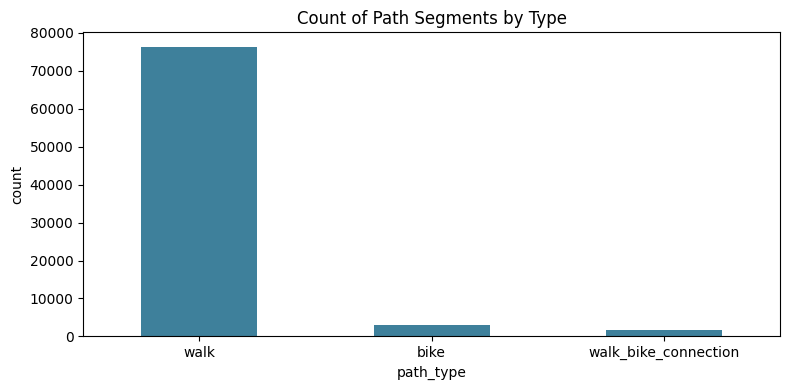

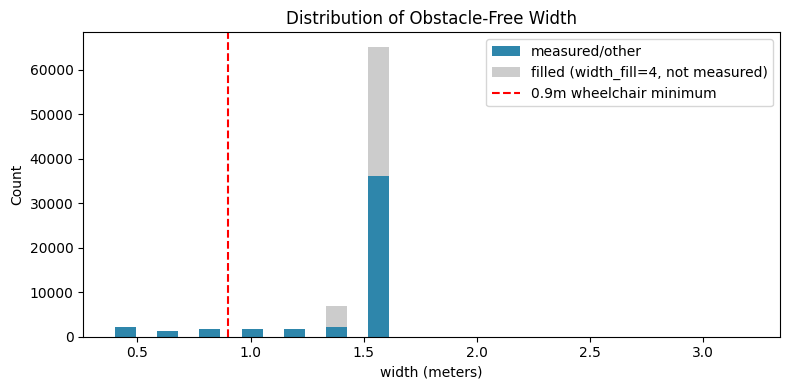

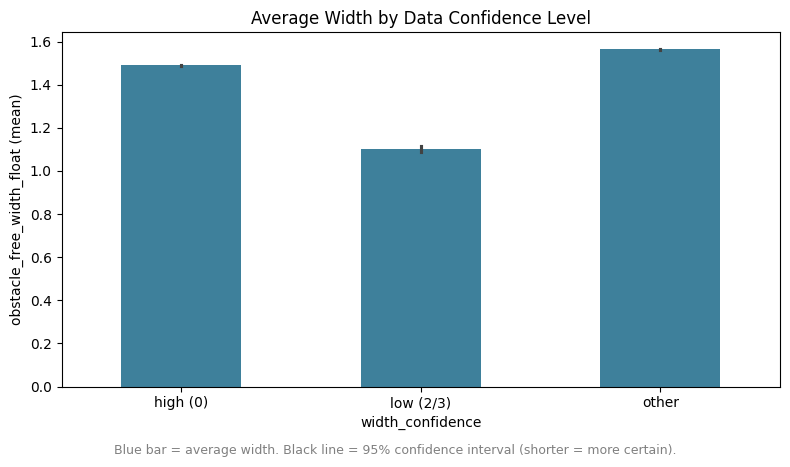

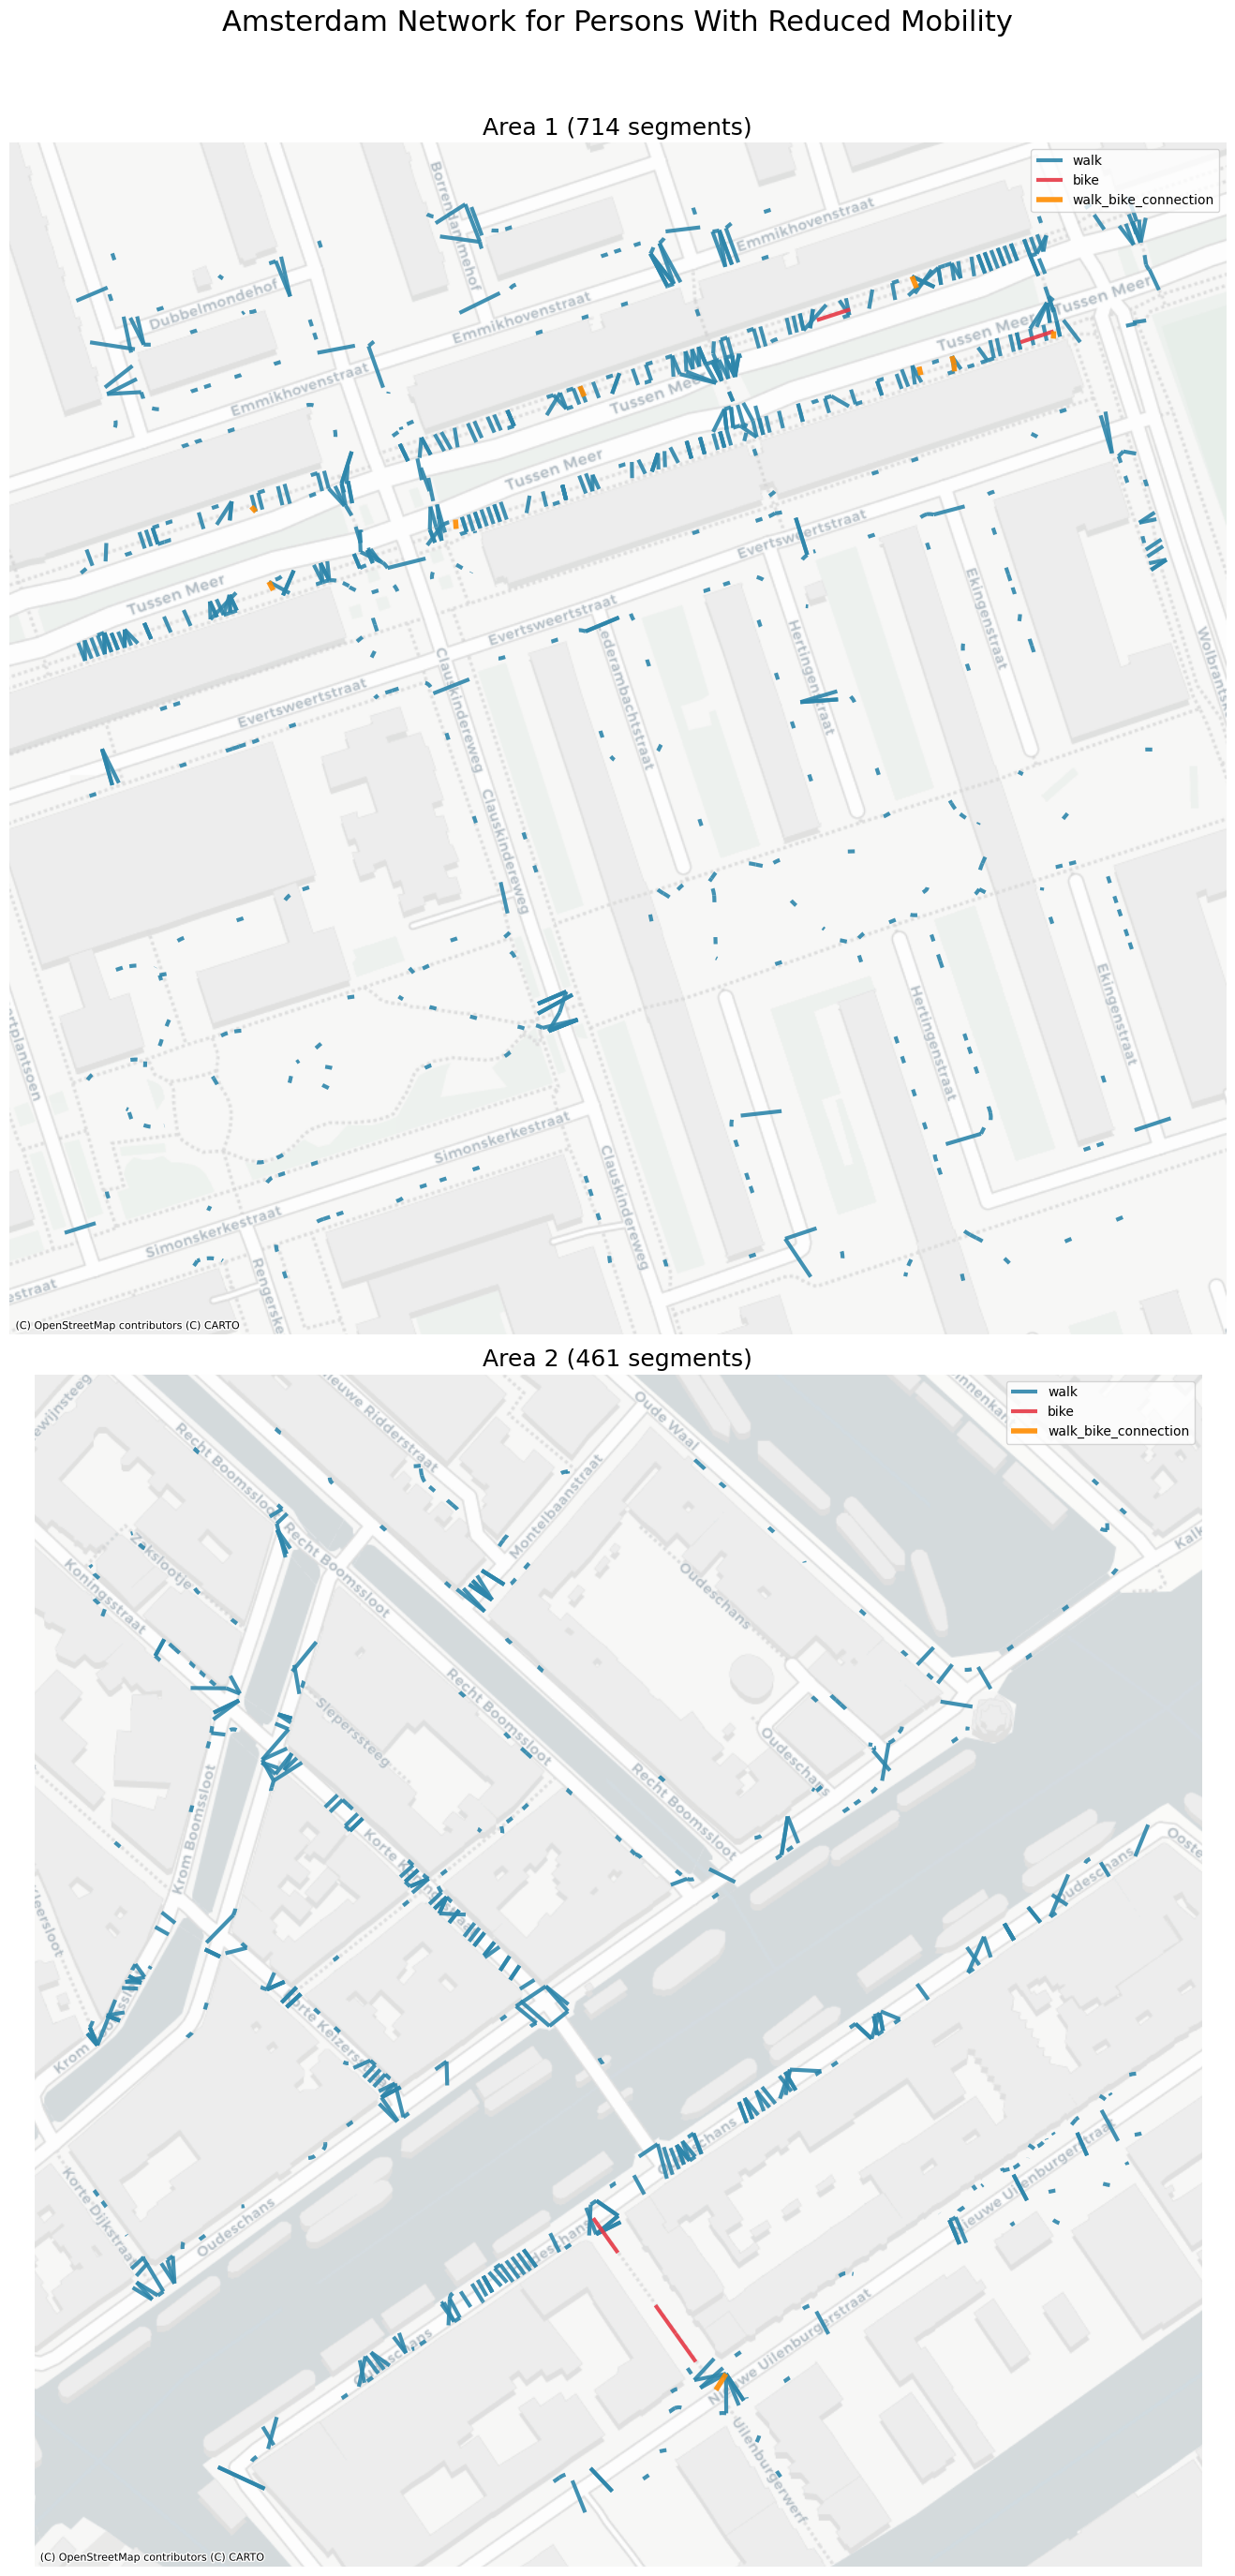

In [1]:
# Step 4: Feature Exploration + Visualization (PMR Network)
# Data Visualization Best Practices
# pip install contextily  (run once, then restart the kernel)
import pyogrio
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx

GPKG_PATH = '../data/raw/accessibility_dataset.gpkg'
layers = pyogrio.list_layers(GPKG_PATH)[:, 0]
gdf = gpd.read_file(GPKG_PATH, layer=layers[0])


def plot_path_type_counts(df):
    # Bar plot: how many segments of each path_type exist.
    # This is a simple count, not an average, so no confidence interval
    # is needed here -- every segment is counted exactly once.
    plt.figure(figsize=(8, 4))
    sns.countplot(x='path_type', data=df, order=df['path_type'].value_counts().index, width=0.5, color='#2E86AB')
    plt.title('Count of Path Segments by Type')
    plt.xlabel('path_type')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()


def plot_width_distribution(df):
    # Histogram of obstacle-free width. Dropping NaN because width only
    # applies to walkable/bikeable segments, not e.g. PT stop markers.
    # A vertical line at 0.9m marks the common minimum wheelchair-passable
    # width used in accessibility guidelines, as a reference point.
    #
    # CHANGED: split by width_fill == 4 (standard filled value for
    # crossings/bike paths, not measured). Without this split, the tall
    # bar at 1.6m looks like real measured width, but ~34% of it is a
    # filled-in constant, not a real sidewalk.
    plt.figure(figsize=(8, 4))
    measured = df[df['width_fill'] != 4]['obstacle_free_width_float'].dropna()
    filled = df[df['width_fill'] == 4]['obstacle_free_width_float'].dropna()
    plt.hist([measured, filled], bins=30, stacked=True,
             color=['#2E86AB', '#CCCCCC'],
             label=['measured/other', 'filled (width_fill=4, not measured)'])
    plt.axvline(0.9, color='red', linestyle='--', label='0.9m wheelchair minimum')
    plt.title('Distribution of Obstacle-Free Width')
    plt.xlabel('width (meters)')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_width_by_confidence(df):
    # Compare width values for high-confidence (width_fill == 0) vs.
    # low-confidence (width_fill in [2, 3]) rows. If the two groups look
    # very different, it means estimated widths could be misleading and
    # should not be trusted the same as measured widths.
    df = df.copy()
    df['width_confidence'] = df['width_fill'].map(
        lambda v: 'high (0)' if v == 0 else ('low (2/3)' if v in [2, 3] else 'other')
    )
    plt.figure(figsize=(8, 4.5))
    sns.barplot(x='width_confidence', y='obstacle_free_width_float', data=df, color='#2E86AB', width=0.5)
    plt.title('Average Width by Data Confidence Level')
    plt.ylabel('obstacle_free_width_float (mean)')

    # Caption below the chart, not on top of it.
    # Explains bar height and the error bar (black line).
    plt.figtext(
        0.5, -0.02,
        'Blue bar = average width. Black line = 95% confidence interval (shorter = more certain).',
        ha='center', fontsize=9, color='gray'
    )

    plt.tight_layout()
    plt.show()


def plot_network_map(df, sample_n=8000, zoom_km=0.5):
    # Map of the network colored by path type, drawn over a real street
    # basemap (like Google Maps) so the network has spatial context.
    # zoom_km controls how much area we crop to, so lines are not too
    # crowded to see clearly.
    plot_df = df.sample(min(sample_n, len(df)), random_state=42).copy()

    # contextily needs Web Mercator (EPSG:3857) to match basemap tiles
    plot_df = plot_df.to_crs(epsg=3857)

    # Auto-detect a district column. If found, plot up to 2 districts
    # stacked. If not found, auto-split by the biggest geographic gap,
    # since this dataset covers two districts that are far apart.
    district_col = next(
        (c for c in plot_df.columns if 'district' in c.lower() or 'buurt' in c.lower() or 'area' in c.lower()),
        None
    )

    if district_col:
        groups = plot_df[district_col].dropna().unique()[:2]
        group_masks = [plot_df[district_col] == g for g in groups]
        group_labels = [str(g) for g in groups]
    else:
        centroids = plot_df.geometry.centroid
        xs, ys = centroids.x.values, centroids.y.values
        vals = xs if (xs.max() - xs.min()) >= (ys.max() - ys.min()) else ys
        order = np.argsort(vals)
        gap_idx = np.argmax(np.diff(vals[order])) + 1
        low_positions = set(order[:gap_idx])
        mask_a = pd.Series(
            [i in low_positions for i in range(len(plot_df))],
            index=plot_df.index
        )
        group_masks = [mask_a, ~mask_a]
        group_labels = ['Area 1', 'Area 2']

    n_maps = len(group_masks)
    fig, axes = plt.subplots(n_maps, 1, figsize=(16, 14 * n_maps))
    axes = [axes] if n_maps == 1 else axes

    path_type_colors = {
        'walk': '#2E86AB',
        'bike': '#E63946',
         'walk_bike_connection': '#FF8C00',   # brighter orange, easier to see
    }

    for ax, mask, label in zip(axes, group_masks, group_labels):
        subset = plot_df[mask]

        # NEW: crop to a small box around the center of this subset,
        # so we zoom into a readable chunk instead of the whole district.
        cx_center = subset.geometry.centroid.x.mean()
        cy_center = subset.geometry.centroid.y.mean()
        half = zoom_km * 1000 / 2
        subset = subset.cx[cx_center - half:cx_center + half, cy_center - half:cy_center + half]

        for ptype, color in path_type_colors.items():
            ptype_subset = subset[subset['path_type'] == ptype]
            if len(ptype_subset) > 0:
                # walk_bike_connection is rare and important, so draw it thicker
                # and last, so it sits on top of walk/bike lines, not under them.
                lw = 4 if ptype == 'walk_bike_connection' else 3
                z = 5 if ptype == 'walk_bike_connection' else 1
                ptype_subset.plot(ax=ax, color=color, linewidth=lw, alpha=0.9, label=ptype, zorder=z)

        # Real street map underneath, light/gray style so colored lines pop
        cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

        # CHANGED: only show legend entries for path types actually
        # present in this subset. Before, the legend always listed all
        # 3 types even when an area had zero bike or walk_bike_connection
        # segments, which looked misleading/empty.
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, loc='upper right')

        ax.set_title(f'{label} ({len(subset)} segments)', fontsize=18)
        ax.set_axis_off()

    plt.suptitle('Amsterdam Network for Persons With Reduced Mobility', fontsize=22)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Run all plots on the PMR dataset
plot_path_type_counts(gdf)
plot_width_distribution(gdf)
plot_width_by_confidence(gdf)
plot_network_map(gdf, zoom_km=0.5)  

## Step 4 Summary - Feature Exploration + Visualization (PMR Network)

### What we found:
- walk is by far the most common path_type (94.1%). bike and
  walk_bike_connection are rare.
- Width histogram: most segments cluster around 1.5-1.6m. But ~34% of
  the tall bar comes from `width_fill == 4` (a filled-in standard
  value, not measured) — split out in gray on the updated chart.
- Width-by-confidence: measured rows average 1.489m, estimated (2/3)
  rows average 1.102m. Estimated widths run narrower.
- The map (sampled for speed) shows sidewalks, bike paths, and
  crossings spread unevenly. Area 1 has some bike/walk_bike_connection
  segments; Area 2 has almost none.

### What this means:
- Path type and width will likely help as features for the
  accessibility score, but width needs the width_fill split to avoid
  overstating how many segments are truly wide.
- Gaps on the map match the "not fully connected" note from the
  dataset. This matters for route planning.

### Next step:
-> Step 5: Export Clean Data

In [1]:
# Step 5: Export Clean Data (PMR Network)
import pyogrio
import geopandas as gpd
import os

GPKG_PATH = '../data/raw/accessibility_dataset.gpkg'
layers = pyogrio.list_layers(GPKG_PATH)[:, 0]
gdf = gpd.read_file(GPKG_PATH, layer=layers[0])

# Remove duplicates one more time before saving (attributes + geometry)
geom_as_text = gdf['geometry'].to_wkt()
dup_mask = gdf.drop(columns='geometry').assign(_geom=geom_as_text).duplicated()
n_before = len(gdf)
gdf = gdf[~dup_mask]
n_dupes_dropped = n_before - len(gdf)

# Carry over the width-quality flag from Step 2/3b so notebook 03 doesn't
# have to recompute it. Codes 2 and 3 are low-confidence (neighbor-guess /
# smallest-category fallback). Code 4 (standard width for crossings/bike
# paths/connections, ~34% of rows) is NOT flagged here -- it's a
# reasonable assumption, not a guess -- but modeling notebooks should
# still consider testing width_fill == 0 separately.
gdf['low_confidence_width'] = gdf['width_fill'].isin([2, 3])

os.makedirs('../data/processed', exist_ok=True)
out_path = '../data/processed/pmr_clean.gpkg'
gdf.to_file(out_path, driver='GPKG')

# Readable summary block
n_low_conf = gdf['low_confidence_width'].sum()
pct_low_conf = gdf['low_confidence_width'].mean() * 100

print("*" * 55)
print("PMR DATA EXPORT SUMMARY")
print("*" * 55)
print(f"Saved to:          {out_path}")
print(f"Rows:              {gdf.shape[0]:,}")
print(f"Columns:           {gdf.shape[1]}")
print(f"Duplicates dropped:{n_dupes_dropped:>7,}")
print("-" * 55)
print("Data Quality")
print(f"  Low-confidence width rows: {n_low_conf:,} ({pct_low_conf:.1f}%)")
print("*" * 55)

*******************************************************
PMR DATA EXPORT SUMMARY
*******************************************************
Saved to:          ../data/processed/pmr_clean.gpkg
Rows:              72,274
Columns:           19
Duplicates dropped:  8,874
-------------------------------------------------------
Data Quality
  Low-confidence width rows: 6,051 (8.4%)
*******************************************************


## Step 5 Summary - Export Clean Data (PMR Network)

### What we did:
- Removed the last duplicates
- Added `low_confidence_width` (True for width_fill codes 2/3) so
  downstream notebooks don't need to recompute it
- Saved the clean data to `data/processed/pmr_clean.gpkg`

### What we found:
- Final shape: 72,274 rows, 19 columns (18 original + `low_confidence_width`)
- 6,051 rows (8.4%) flagged as low-confidence width

### Next step:
-> Notebook 02: Explore the Housing and Accessibility dataset
-> Notebook 03: Build features and models for PMR and Housing
   separately (not merged -- see notebook 03 intro for why)